<a href="https://colab.research.google.com/github/choihj-01/Hybrid-Model-Attention/blob/main/CNN_LSTM_att_0325_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout, LeakyReLU, ReLU
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam, Adamax
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.models import load_model
!pip install keras-self-attention
from keras_self_attention import SeqSelfAttention
import time
import argparse
import pickle

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=cf63477c312193a15971df804c31f9fe1955138acbffa4fa60a5e8bf555de877
  Stored in directory: /root/.cache/pip/wheels/9a/9d/6e/09a0f61c2edeaea9f96fecdc67f31455c363bb44a4ddabe746
Successfully built keras-self-attention


In [2]:
parser = argparse.ArgumentParser()
parser.add_argument('--array', type=int, required=True)
# For interactive environments like Colab, provide arguments explicitly
args = parser.parse_args(['--array', '5']) # Example: setting --array to 5

number = np.arange(0,10,1)
number = number[args.array]

In [3]:
temperature_dirs = ['0degC/', '10degC/', '25degC/', '-10degC/']

In [15]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#Load dataset

import os
import pickle
import numpy as np

# [1] pkl 경로 설정
# Colab 예시:
PKL_PATH = "/Panasonic_data.pkl"
# 로컬 예시:
# PKL_PATH = "./Panasonic_data.pkl"

if not os.path.exists(PKL_PATH):
    raise FileNotFoundError(f"Panasonic_data.pkl not found: {PKL_PATH}")

with open(PKL_PATH, "rb") as f:
    pano = pickle.load(f)

print("✅ pkl loaded:", PKL_PATH)
print("✅ deg keys:", list(pano.keys())[:10])

# [2] 온도 디렉토리 표기 통일 함수
def _norm_deg_key(deg):
    return str(deg).rstrip("/")

# [3] 배열 길이 맞추기 + NaN 제거 유틸
def _sanitize_cycle_arrays(voltage, current, temperature, soc):
    v = np.asarray(voltage, dtype=float)
    i = np.asarray(current, dtype=float)
    t = np.asarray(temperature, dtype=float)
    s = np.asarray(soc, dtype=float)

    n = min(len(v), len(i), len(t), len(s))
    v, i, t, s = v[:n], i[:n], t[:n], s[:n]

    mask = np.isfinite(v) & np.isfinite(i) & np.isfinite(t) & np.isfinite(s)
    v, i, t, s = v[mask], i[mask], t[mask], s[mask]

    return v, i, t, s

def timeorder(cycles_order):
    x_length = len(cycles_order[0][0][0])
    y_length = len(cycles_order[0][1][0])
    x = np.zeros((0, x_length), float)
    y = np.zeros((0, y_length), float)
    prev_cycle_x = np.zeros((100, x_length), float)
    prev_cycle_y = np.zeros((100, y_length), float)
    for cycle_order in cycles_order:
        next_cycle_x = np.array(cycle_order[0])
        next_cycle_y = np.array(cycle_order[1])
        next_cycle_x[:,0] = next_cycle_x[:,0] - (next_cycle_x[:,0][0] - prev_cycle_x[:,0][-1])
        next_cycle_y[:,0] = next_cycle_y[:,0] - (next_cycle_y[:,0][0] - prev_cycle_y[:,0][-1])
        prev_cycle_x = next_cycle_x
        prev_cycle_y = next_cycle_y
        #rint(prev_cycle_x[:,0][0])
        #rint(prev_cycle_x[:,0][-1])
        x = np.concatenate((x, next_cycle_x))
        y = np.concatenate((y, next_cycle_y))
    return x, y

def average(xtraingroup, steps):
    x_V = np.zeros((0), float)
    x_I = np.zeros((0), float)
    for i in range(0, len(xtraingroup) - steps, 1):
        next_V = np.mean(xtraingroup[i:i + steps,0]).reshape(-1)
        next_I = np.mean(xtraingroup[i:i + steps,1]).reshape(-1)
        x_V = np.concatenate((x_V, next_V))
        x_I = np.concatenate((x_I, next_I))
    return x_V, x_I


def get_data_up_pkl(names_by_deg, deg_dirs, pano_dict):
    cycles = []
    missing = []

    for idx, deg in enumerate(deg_dirs):
        deg_key = _norm_deg_key(deg)
        if deg_key not in pano_dict:
            missing.append(f"[missing deg] {deg_key}")
            continue

        for cyc_name in names_by_deg[idx]:
            if cyc_name not in pano_dict[deg_key]:
                missing.append(f"[missing cycle] {deg_key}/{cyc_name}")
                continue

            d = pano_dict[deg_key][cyc_name]
            v, i, temp, soc = _sanitize_cycle_arrays(
                d["voltage"], d["current"], d["temperature"], d["soc"]
            )

            # 기존 코드에서 timeorder가 시간축(t)을 이어붙이는 로직이라
            # 여기서는 단순 인덱스 시간 사용
            t_axis = np.arange(len(v), dtype=float)

            # 기존 get_data_up 포맷 맞춤
            # x: [Time, Voltage, Current, Temperature]
            # y: [Time, SoC]
            x = np.stack([t_axis, v, i, temp], axis=1)
            y = np.stack([t_axis, soc], axis=1)

            cycles.append((x, y))

    if missing:
        print("⚠️ missing entries (first 20):")
        for m in missing[:20]:
            print(" -", m)
        if len(missing) > 20:
            print(f" ... and {len(missing)-20} more")

    print(f"✅ get_data_up_pkl built cycles: {len(cycles)}")
    return cycles

def data_test_pkl(cycle_name, deg, pano_dict):
    deg_key = _norm_deg_key(deg)
    if deg_key not in pano_dict:
        raise KeyError(f"deg key not found in pkl: {deg_key}")
    if cycle_name not in pano_dict[deg_key]:
        raise KeyError(f"cycle not found in pkl: {deg_key}/{cycle_name}")

    d = pano_dict[deg_key][cycle_name]
    v, i, temp, soc = _sanitize_cycle_arrays(
        d["voltage"], d["current"], d["temperature"], d["soc"]
    )

    t_axis = np.arange(len(v), dtype=float)
    x = np.stack([t_axis, v, i, temp], axis=1)
    y = np.stack([t_axis, soc], axis=1)

    return [(x, y)]


Num GPUs Available:  1
✅ pkl loaded: /Panasonic_data.pkl
✅ deg keys: ['-10degC', '-20degC', '0degC', '10degC', '25degC']


In [16]:
test_file_pairs = [
    ('0degC/',  'UDDS'),
    ('0degC/',  'US06'),
    ('10degC/', 'US06'),
    ('10degC/', 'US06_HWFET_UDDS_LA92_NN'),
    ('25degC/', 'HWFTa'),
    ('25degC/', 'HWFTb'),
    ('-10degC/','US06'),
    ('-10degC/','US06_HWFET_UDDS_LA92'),
]

In [17]:
# 0degC
train_names_0 = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN']
test_names_0  = ['UDDS', 'US06']

# 10degC
train_names_10 = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN', 'UDDS']
test_names_10  = ['US06', 'US06_HWFET_UDDS_LA92_NN']

# 25degC
train_names_25 = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'LA92', 'NN', 'UDDS', 'US06']
test_names_25  = ['HWFTa', 'HWFTb']

# n10degC (pkl 내부 '-10degC'에 매핑됨)
train_names_n10 = ['Cycle_1', 'Cycle_2', 'Cycle_3', 'Cycle_4', 'HWFET', 'LA92', 'NN', 'UDDS']
test_names_n10  = ['US06', 'US06_HWFET_UDDS_LA92']

train_names_all = [train_names_0, train_names_10, train_names_25, train_names_n10]
test_names_all  = [test_names_0,  test_names_10,  test_names_25,  test_names_n10]

In [18]:
cycles_train = get_data_up_pkl(train_names_all, temperature_dirs, pano)
x_train_order, y_train_order = timeorder(cycles_train)

cycles_test = get_data_up_pkl(test_names_all, temperature_dirs, pano)
x_test_order, y_test_order = timeorder(cycles_test)


df_xtrain = pd.DataFrame(x_train_order)
df_ytrain = pd.DataFrame(y_train_order)
df_ytrain.columns =['t', 'SOC']
df_xtrain.columns =['t', 'V', 'I', 'T']

df_xtest = pd.DataFrame(x_test_order)
df_ytest = pd.DataFrame(y_test_order)
df_ytest.columns =['t', 'SOC']
df_xtest.columns =['t', 'V', 'I', 'T']


cols_to_norm = ['V','I','T']
cols_to_norm_new = ['V_norm','I_norm','T_norm']
df_xtrain[cols_to_norm_new] = df_xtrain[cols_to_norm].apply(lambda x: (x - x.min()) / (x.max() - x.min()))
df_xtest[cols_to_norm_new] = df_xtest[cols_to_norm].apply(lambda x: (x - x.min()) / (x.max() - x.min()))


df_xtrain_reset = df_xtrain.groupby(['t']).mean().reset_index()
df_xtrain_group = df_xtrain.groupby(['t']).mean()
df_ytrain_reset = df_ytrain.groupby(['t']).mean().reset_index()
df_ytrain_group = df_ytrain.groupby(['t']).mean()

#각 파일별 성능
train_minmax = {
    'V': (df_xtrain_reset['V'].min(), df_xtrain_reset['V'].max()),
    'I': (df_xtrain_reset['I'].min(), df_xtrain_reset['I'].max()),
    'T': (df_xtrain_reset['T'].min(), df_xtrain_reset['T'].max()),
}


df_xtest_reset = df_xtest.groupby(['t']).mean().reset_index()
df_xtest_group = df_xtest.groupby(['t']).mean()

df_ytest_reset = df_ytest.groupby(['t']).mean().reset_index()
df_ytest_group = df_ytest.groupby(['t']).mean()

xtrain_group = np.array(df_xtrain_group[['V_norm', 'I_norm']])
xtest_group = np.array(df_xtest_group[['V_norm', 'I_norm']])

k=400

V_avg, I_avg = average(xtrain_group, k)
V_avg_test, I_avg_test = average(xtest_group, k)

df_V_avg = pd.DataFrame(V_avg)
df_I_avg = pd.DataFrame(I_avg)
df_V_avg.columns =['V_avg']
df_I_avg.columns =['I_avg']

df_V_avg_test = pd.DataFrame(V_avg_test)
df_I_avg_test = pd.DataFrame(I_avg_test)
df_V_avg_test.columns =['V_avg']
df_I_avg_test.columns =['I_avg']

df_tot =  pd.concat([df_xtrain_reset, df_V_avg, df_I_avg], axis=1)
df_tot_test =  pd.concat([df_xtest_reset, df_V_avg_test, df_I_avg_test], axis=1)


df_tot['V_avg'] =df_tot.V_avg.shift(periods=k)
df_tot['I_avg'] =df_tot.I_avg.shift(periods=k)
df_tot.loc[:k, 'V_avg'] = df_tot['V_avg'][k+1]
df_tot.loc[:k, 'I_avg'] = df_tot['I_avg'][k+1]

df_tot_test['V_avg'] =df_tot_test.V_avg.shift(periods=k)
df_tot_test['I_avg'] =df_tot_test.I_avg.shift(periods=k)
df_tot_test.loc[:k, 'V_avg'] = df_tot_test['V_avg'][k+1]
df_tot_test.loc[:k, 'I_avg'] = df_tot_test['I_avg'][k+1]


dftrain_x = df_tot[['V_norm', 'I_norm', 'T_norm', 'V_avg', 'I_avg']]
dftest_x = df_tot_test[['V_norm', 'I_norm', 'T_norm', 'V_avg', 'I_avg']]
dftrain_y = df_ytrain_reset['SOC']
dftest_y = df_ytest_reset['SOC']



train_X = dftrain_x.to_numpy()
test_X = dftest_x.to_numpy()
train_y = dftrain_y.to_numpy()
test_y = dftest_y.to_numpy()


train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))

train_y = train_y.reshape((train_y.shape[0]))
test_y = test_y.reshape((test_y.shape[0]))

print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)


n_features = 5
n_seq = 1
n_steps = 1
train_X = train_X.reshape((train_X.shape[0], n_seq, n_features, n_steps))
test_X = test_X.reshape((test_X.shape[0], n_seq, n_features, n_steps))

print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

⚠️ missing entries (first 20):
 - [missing deg] n10degC
✅ get_data_up_pkl built cycles: 23
⚠️ missing entries (first 20):
 - [missing deg] n10degC
✅ get_data_up_pkl built cycles: 6
(2377955, 1, 5) (2377955,) (914227, 1, 5) (914227,)
(2377955, 1, 5, 1) (2377955,) (914227, 1, 5, 1) (914227,)


In [19]:
def create_Cnn_lstm(optimizations,latent_dimension,loss_function,conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    unit3 = latent_dimension[2]
    cnn1 = conv_dimension[0]
    cnn2 = conv_dimension[1]
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn1, kernel_size=3, kernel_initializer='he_uniform', activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Conv1D(filters=cnn2, kernel_size=3, kernel_initializer='he_uniform', activation='relu')))
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(unit1, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(LSTM(unit2, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(LSTM(unit3, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=False))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    #model.add(ReLU(max_value=1.0))
    print("Params: "+str(model.count_params()))
    model.compile(optimizer=optimizations, loss=loss_function)
    return model

def build_test_xy_for_one_file(namedeg, filename, train_minmax, k=400):
    cycles = data_test_pkl(filename, namedeg, pano)
    x_order, y_order = timeorder(cycles)

    df_x = pd.DataFrame(x_order, columns=['t', 'V', 'I', 'T'])
    df_y = pd.DataFrame(y_order, columns=['t', 'SOC'])

    df_x_reset = df_x.groupby(['t']).mean().reset_index()
    df_x_group = df_x.groupby(['t']).mean()
    df_y_reset = df_y.groupby(['t']).mean().reset_index()

    Vmin, Vmax = train_minmax['V']
    Imin, Imax = train_minmax['I']
    Tmin, Tmax = train_minmax['T']

    # 분모 0 방지
    eps = 1e-12
    df_x_reset['V_norm'] = (df_x_reset['V'] - Vmin) / (Vmax - Vmin + eps)
    df_x_reset['I_norm'] = (df_x_reset['I'] - Imin) / (Imax - Imin + eps)
    df_x_reset['T_norm'] = (df_x_reset['T'] - Tmin) / (Tmax - Tmin + eps)

    x_group_norm = np.array(df_x_reset[['V_norm','I_norm']])
    V_avg, I_avg = average(x_group_norm, k)

    df_V_avg = pd.DataFrame(V_avg, columns=['V_avg'])
    df_I_avg = pd.DataFrame(I_avg, columns=['I_avg'])

    # 길이 맞춤 (average 결과가 짧을 수 있음)
    min_len = min(len(df_x_reset), len(df_V_avg), len(df_I_avg), len(df_y_reset))
    df_x_reset = df_x_reset.iloc[:min_len].reset_index(drop=True)
    df_y_reset = df_y_reset.iloc[:min_len].reset_index(drop=True)
    df_V_avg = df_V_avg.iloc[:min_len].reset_index(drop=True)
    df_I_avg = df_I_avg.iloc[:min_len].reset_index(drop=True)

    df_tot_test = pd.concat([df_x_reset, df_V_avg, df_I_avg], axis=1)

    if min_len > k + 1:
        df_tot_test['V_avg'] = df_tot_test['V_avg'].shift(periods=k)
        df_tot_test['I_avg'] = df_tot_test['I_avg'].shift(periods=k)
        df_tot_test.loc[:k, 'V_avg'] = df_tot_test['V_avg'].iloc[k+1]
        df_tot_test.loc[:k, 'I_avg'] = df_tot_test['I_avg'].iloc[k+1]
    else:
        # 데이터가 짧으면 shift 생략
        pass

    dftest_x = df_tot_test[['V_norm', 'I_norm', 'T_norm', 'V_avg', 'I_avg']].fillna(method='bfill').fillna(method='ffill')
    dftest_y = df_y_reset['SOC']

    test_X = dftest_x.to_numpy()
    test_y = dftest_y.to_numpy().reshape(-1)

    test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))  # (N,1,5)
    n_features = 5
    n_seq = 1
    n_steps = 1
    test_X = test_X.reshape((test_X.shape[0], n_seq, n_features, n_steps))  # (N,1,5,1)

    return test_X, test_y

print("✅ Adapter ready. Replace completed.")


✅ Adapter ready. Replace completed.


In [28]:
def Optimize(opts,dim,loss,conv,numbers,batch,epoch=100,verbose=0):
    model_generated = " batch: "+str(batch)+" | dim: "+str(dim)+" | loss: "+str(loss)+" | epoch: "+str(epoch)
    model = None
    model = create_Cnn_lstm(opts,dim,loss,conv)
    t0 = time.time()
    history_temp = model.fit(train_X, train_y, epochs=epoch, batch_size=batch, validation_data=(test_X, test_y), verbose=verbose)

    # ===== 모델 저장 =====
    save_path = f"/content/drive/MyDrive/models/model_CNN_LSTM_att_{numbers}.keras" # Updated to save to Google Drive
    # Ensure the directory exists before saving
    import os
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save(save_path)
    # =====================
    '''
    ########################################
        # === [추가] 12개 test 파일 개별 평가 ===
    per_file_results = []
    for deg, fname in test_file_pairs:
        one_test_X, one_test_y = build_test_xy_for_one_file(
            namedeg=deg,
            filename=fname,
            train_minmax=train_minmax,
            k=400
        )

        one_pred = model.predict(one_test_X, verbose=0).reshape(-1)
        rmse = np.sqrt(mean_squared_error(one_test_y, one_pred))
        mae  = mean_absolute_error(one_test_y, one_pred)

        per_file_results.append((deg + fname, rmse, mae))

    # RMSE 우선, 동률이면 MAE로 정렬
    per_file_results.sort(key=lambda x: (x[1], x[2]))
    print("---------------------------------------------------------------------")
    print("\n[Top-2 Best Test Files by (RMSE, MAE)]")
    for r in per_file_results[:2]:
        print(f"{r[0]}  | RMSE={r[1]:.6f} | MAE={r[2]:.6f}")
    #25degC/552_Mixed6에 대한 그래프
    one_test_X25_552, one_test_y25_552 = build_test_xy_for_one_file(
            namedeg='25degC/',
            filename='552_Mixed6',
            train_minmax=train_minmax,
            k=400
        )
    one_pred25_552 = model.predict(one_test_X25_552, verbose=0).reshape(-1)
    plt.figure()
    plt.plot(one_test_y25_552, label='True (test) with 25degC/552_Mixed6')
    plt.plot(one_pred25_552, label='Predicted with 25degC/552_Mixed6')
    plt.xlabel('Time step')
    plt.ylabel('SoC')
    plt.title('Test Data: 25degC/552_Mixed6')
    plt.legend()
    plt.grid(True)
    plt.show()
    #10degC/567_US06에 대한 그래프
    one_test_X10_567, one_test_y10_567 = build_test_xy_for_one_file(
            namedeg='10degC/',
            filename='567_US06',
            train_minmax=train_minmax,
            k=400
        )
    one_pred10_567 = model.predict(one_test_X10_567, verbose=0).reshape(-1)
    plt.figure()
    plt.plot(one_test_y10_567, label='True (test) with 10degC/567_US06')
    plt.plot(one_pred10_567, label='Predicted with 10degC/567_US06')
    plt.xlabel('Time step')
    plt.ylabel('SoC')
    plt.title('Test Data: 10degC/567_US06')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("---------------------------------------------------------------------")
    '''
##################################################
    print("Training time:", time.time()-t0)
    #print('Predict')
    y_predict = model.predict(test_X,verbose=0)
    print('compute RMSE,MAE')
    y_predict = y_predict.reshape(y_predict.shape[0])
    rmse_temp = np.sqrt(mean_squared_error(test_y, y_predict))
    temo_loss = " | loss: " + str(history_temp.history['loss'][epoch-1]) + " | val_loss: " + str(history_temp.history["val_loss"][epoch-1])
    MAE = mean_absolute_error(test_y, y_predict)
    temp_result = "rmse: "+str(rmse_temp)+"MAE:" + str(MAE) +" " + temo_loss +" " + model_generated
    print(opts)
    print(dim)
    print(loss)
    print(temp_result)
    fig = plt.figure()
    plt.plot(history_temp.history['loss'])
    plt.plot(history_temp.history['val_loss'])
    plt.title('model loss')
    plt.yscale('log')
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    #plt.legend(['train', 'test'], loc='upper right')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.annotate("rmse = {:.5f} , mae = {:.5f}, training time = {:.3f}".format(rmse_temp, MAE, (time.time()-t0)/ 60.0), (100, 0.01))
    # Save plot to Google Drive
    plt.savefig(f'/content/drive/MyDrive/models/stacked-CNN1LSTM3layer-att-dim: {dim} loss: {loss} opt: {opts} conv: {conv}_{numbers}.png')
    # Save history to Google Drive
    f_path = f'/content/drive/MyDrive/models/history500_{numbers}.pckl'
    os.makedirs(os.path.dirname(f_path), exist_ok=True)
    with open(f_path, 'wb') as f:
        pickle.dump(history_temp.history, f)

    plt.figure()
    plt.plot(test_y, label='True (test)')
    plt.plot(y_predict, label='Predicted')
    plt.xlabel('Time step')
    plt.ylabel('SoC')
    plt.title('Test Data: True vs Predicted')
    plt.legend()
    plt.grid(True)
    plt.show()


    return temp_result

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [31]:
model = load_model(f"/content/drive/MyDrive/models/model_CNN_LSTM_att_5.keras", custom_objects={'SeqSelfAttention': SeqSelfAttention})
# === [추가] 12개 test 파일 개별 평가 ===
per_file_results = []
for deg, fname in test_file_pairs:
    one_test_X, one_test_y = build_test_xy_for_one_file(
        namedeg=deg,
        filename=fname,
        train_minmax=train_minmax,
        k=400
    )

    one_pred = model.predict(one_test_X, verbose=0).reshape(-1)
    rmse = np.sqrt(mean_squared_error(one_test_y, one_pred))
    mae  = mean_absolute_error(one_test_y, one_pred)

    per_file_results.append((deg + fname, rmse, mae))

# RMSE 우선, 동률이면 MAE로 정렬
per_file_results.sort(key=lambda x: (x[1], x[2]))
print("---------------------------------------------------------------------")
print("\n[Top-2 Best Test Files by (RMSE, MAE)]")
for r in per_file_results[:2]:
    print(f"{r[0]}  | RMSE={r[1]:.6f} | MAE={r[2]:.6f}")
#25degC/552_Mixed6에 대한 그래프
one_test_X25_552, one_test_y25_552 = build_test_xy_for_one_file(
        namedeg='25degC/',
        filename='552_Mixed6',
        train_minmax=train_minmax,
        k=400
    )
one_pred25_552 = model.predict(one_test_X25_552, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y25_552, label='True (test) with 25degC/552_Mixed6')
plt.plot(one_pred25_552, label='Predicted with 25degC/552_Mixed6')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 25degC/552_Mixed6')
plt.legend()
plt.grid(True)
plt.show()
#10degC/567_US06에 대한 그래프
one_test_X10_567, one_test_y10_567 = build_test_xy_for_one_file(
        namedeg='10degC/',
        filename='567_US06',
        train_minmax=train_minmax,
        k=400
    )
one_pred10_567 = model.predict(one_test_X10_567, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y10_567, label='True (test) with 10degC/567_US06')
plt.plot(one_pred10_567, label='Predicted with 10degC/567_US06')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 10degC/567_US06')
plt.legend()
plt.grid(True)
plt.show()

print("---------------------------------------------------------------------")

ValueError: File not found: filepath=/content/drive/MyDrive/models/model_CNN_LSTM_att_5.keras. Please ensure the file is an accessible `.keras` zip file.

---------------------------------------------------------------------

[Top-2 Best Test Files by (RMSE, MAE)]
10degC/567_US06  | RMSE=0.036208 | MAE=0.025836
0degC/590_Mixed7  | RMSE=0.037269 | MAE=0.031929


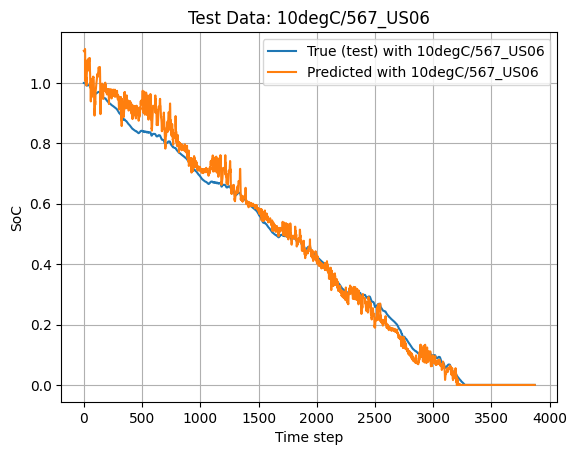

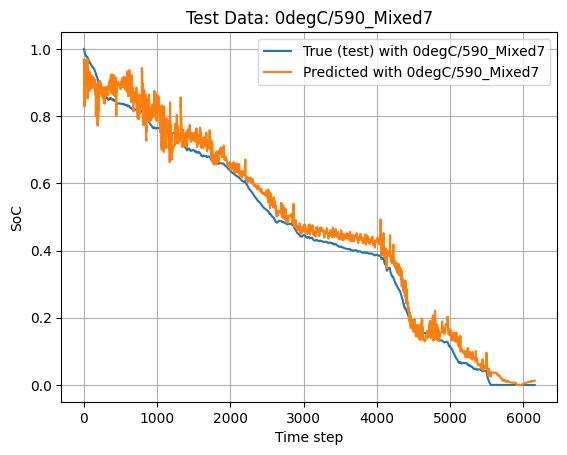

---------------------------------------------------------------------


In [ ]:
model = load_model(f"/content/drive/MyDrive/models/model_CNN2_BILSTM3_att.keras", custom_objects={'SeqSelfAttention': SeqSelfAttention})
# === [추가] 12개 test 파일 개별 평가 ===
per_file_results = []
for deg, fname in test_file_pairs:
    one_test_X, one_test_y = build_test_xy_for_one_file(
        namedeg=deg,
        filename=fname,
        train_minmax=train_minmax,
        k=400
    )

    one_pred = model.predict(one_test_X, verbose=0).reshape(-1)
    rmse = np.sqrt(mean_squared_error(one_test_y, one_pred))
    mae  = mean_absolute_error(one_test_y, one_pred)

    per_file_results.append((deg + fname, rmse, mae))

# RMSE 우선, 동률이면 MAE로 정렬
per_file_results.sort(key=lambda x: (x[1], x[2]))
print("---------------------------------------------------------------------")
print("\n[Top-2 Best Test Files by (RMSE, MAE)]")
for r in per_file_results[:2]:
    print(f"{r[0]}  | RMSE={r[1]:.6f} | MAE={r[2]:.6f}")
#10degC/567_US06에 대한 그래프
one_test_X10_567, one_test_y10_567 = build_test_xy_for_one_file(
        namedeg='10degC/',
        filename='567_US06',
        train_minmax=train_minmax,
        k=400
    )
one_pred10_567 = model.predict(one_test_X10_567, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y10_567, label='True (test) with 10degC/567_US06')
plt.plot(one_pred10_567, label='Predicted with 10degC/567_US06')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 10degC/567_US06')
plt.legend()
plt.grid(True)
plt.show()
#0degC/590_Mixed7에 대한 그래프
one_test_X0_590, one_test_y0_590 = build_test_xy_for_one_file(
        namedeg='0degC/',
        filename='590_Mixed7',
        train_minmax=train_minmax,
        k=400
    )
one_pred0_590 = model.predict(one_test_X0_590, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y0_590, label='True (test) with 0degC/590_Mixed7')
plt.plot(one_pred0_590, label='Predicted with 0degC/590_Mixed7')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 0degC/590_Mixed7')
plt.legend()
plt.grid(True)
plt.show()

print("---------------------------------------------------------------------")

---------------------------------------------------------------------

[Top-2 Best Test Files by (RMSE, MAE)]
25degC/552_Mixed6  | RMSE=0.028618 | MAE=0.023903
25degC/552_Mixed7  | RMSE=0.032564 | MAE=0.026855


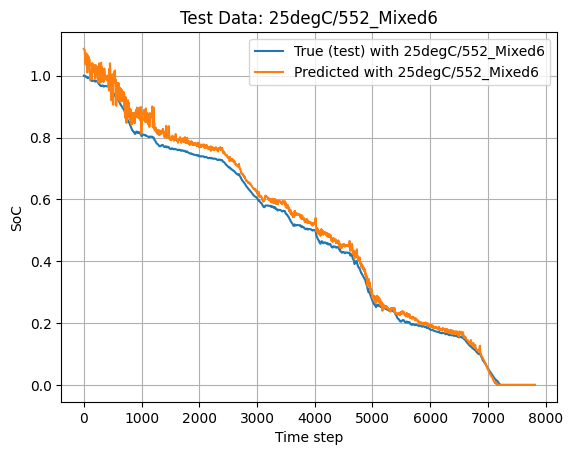

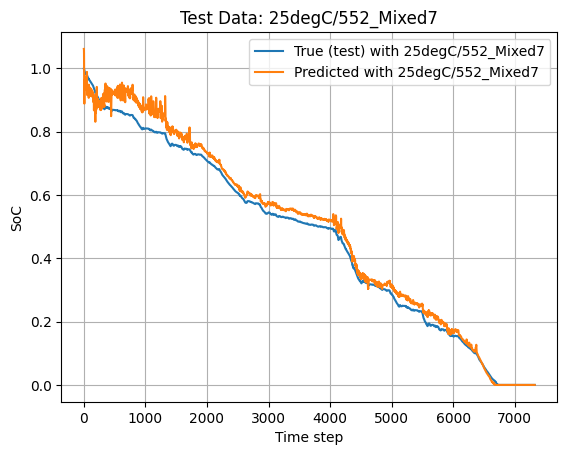

---------------------------------------------------------------------


In [ ]:
model = load_model(f"/content/drive/MyDrive/models/model_CNN1_BILSTM2_att.keras", custom_objects={'SeqSelfAttention': SeqSelfAttention})
# === [추가] 12개 test 파일 개별 평가 ===
per_file_results = []
for deg, fname in test_file_pairs:
    one_test_X, one_test_y = build_test_xy_for_one_file(
        namedeg=deg,
        filename=fname,
        train_minmax=train_minmax,
        k=400
    )

    one_pred = model.predict(one_test_X, verbose=0).reshape(-1)
    rmse = np.sqrt(mean_squared_error(one_test_y, one_pred))
    mae  = mean_absolute_error(one_test_y, one_pred)

    per_file_results.append((deg + fname, rmse, mae))

# RMSE 우선, 동률이면 MAE로 정렬
per_file_results.sort(key=lambda x: (x[1], x[2]))
print("---------------------------------------------------------------------")
print("\n[Top-2 Best Test Files by (RMSE, MAE)]")
for r in per_file_results[:2]:
    print(f"{r[0]}  | RMSE={r[1]:.6f} | MAE={r[2]:.6f}")
#25degC/552_Mixed6에 대한 그래프
one_test_X25_552, one_test_y25_552 = build_test_xy_for_one_file(
        namedeg='25degC/',
        filename='552_Mixed6',
        train_minmax=train_minmax,
        k=400
    )
one_pred25_552 = model.predict(one_test_X25_552, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y25_552, label='True (test) with 25degC/552_Mixed6')
plt.plot(one_pred25_552, label='Predicted with 25degC/552_Mixed6')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 25degC/552_Mixed6')
plt.legend()
plt.grid(True)
plt.show()
#25degC/552_Mixed7에 대한 그래프
one_test_X25_552_7, one_test_y25_552_7 = build_test_xy_for_one_file(
        namedeg='25degC/',
        filename='552_Mixed7',
        train_minmax=train_minmax,
        k=400
    )
one_pred25_552_7 = model.predict(one_test_X25_552_7, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y25_552_7, label='True (test) with 25degC/552_Mixed7')
plt.plot(one_pred25_552_7, label='Predicted with 25degC/552_Mixed7')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 25degC/552_Mixed7')
plt.legend()
plt.grid(True)
plt.show()

print("---------------------------------------------------------------------")

---------------------------------------------------------------------

[Top-2 Best Test Files by (RMSE, MAE)]
25degC/552_Mixed6  | RMSE=0.034262 | MAE=0.030116
10degC/567_US06  | RMSE=0.034953 | MAE=0.026227


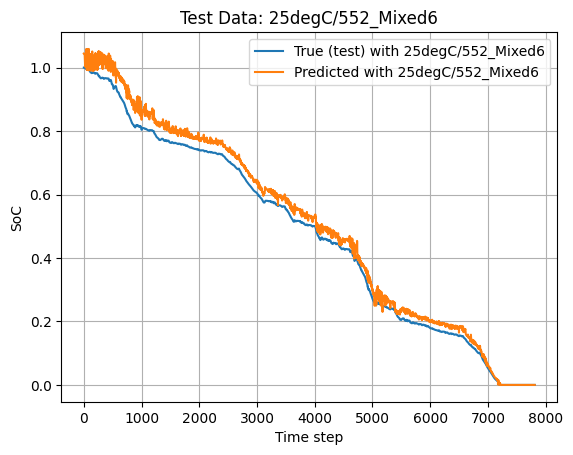

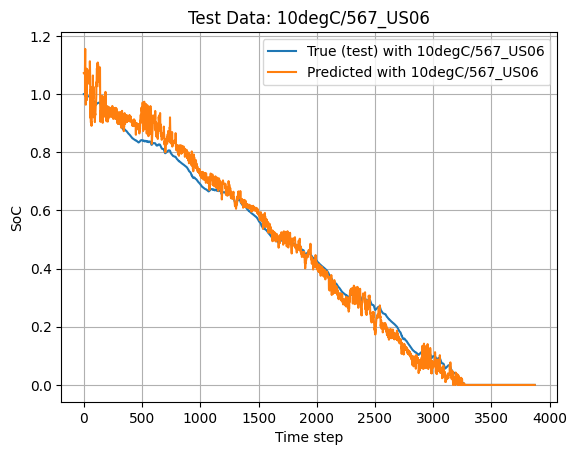

---------------------------------------------------------------------


In [ ]:
model = load_model(f"/content/drive/MyDrive/models/model_CNN_LSTM_att.keras", custom_objects={'SeqSelfAttention': SeqSelfAttention})
# === [추가] 12개 test 파일 개별 평가 ===
per_file_results = []
for deg, fname in test_file_pairs:
    one_test_X, one_test_y = build_test_xy_for_one_file(
        namedeg=deg,
        filename=fname,
        train_minmax=train_minmax,
        k=400
    )

    one_pred = model.predict(one_test_X, verbose=0).reshape(-1)
    rmse = np.sqrt(mean_squared_error(one_test_y, one_pred))
    mae  = mean_absolute_error(one_test_y, one_pred)

    per_file_results.append((deg + fname, rmse, mae))

# RMSE 우선, 동률이면 MAE로 정렬
per_file_results.sort(key=lambda x: (x[1], x[2]))
print("---------------------------------------------------------------------")
print("\n[Top-2 Best Test Files by (RMSE, MAE)]")
for r in per_file_results[:2]:
    print(f"{r[0]}  | RMSE={r[1]:.6f} | MAE={r[2]:.6f}")
#25degC/552_Mixed6에 대한 그래프
one_test_X25_552, one_test_y25_552 = build_test_xy_for_one_file(
        namedeg='25degC/',
        filename='552_Mixed6',
        train_minmax=train_minmax,
        k=400
    )
one_pred25_552 = model.predict(one_test_X25_552, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y25_552, label='True (test) with 25degC/552_Mixed6')
plt.plot(one_pred25_552, label='Predicted with 25degC/552_Mixed6')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 25degC/552_Mixed6')
plt.legend()
plt.grid(True)
plt.show()
#10degC/567_US06에 대한 그래프
one_test_X10_567, one_test_y10_567 = build_test_xy_for_one_file(
        namedeg='10degC/',
        filename='567_US06',
        train_minmax=train_minmax,
        k=400
    )
one_pred10_567 = model.predict(one_test_X10_567, verbose=0).reshape(-1)
plt.figure()
plt.plot(one_test_y10_567, label='True (test) with 10degC/567_US06')
plt.plot(one_pred10_567, label='Predicted with 10degC/567_US06')
plt.xlabel('Time step')
plt.ylabel('SoC')
plt.title('Test Data: 10degC/567_US06')
plt.legend()
plt.grid(True)
plt.show()

print("---------------------------------------------------------------------")

In [ ]:
latent_dimension=[[110,90,70],[110, 90, 70],[128, 64, 32]]
conv_dimension=[[8,8],[16, 8], [16, 16]]
loss_function=['mse']
optimizations=[Adam(learning_rate=1e-4), Adam(learning_rate=5e-4), Adam(learning_rate=1e-3)]
batch_sizes = [256, 512]

result = []
run_id = 0

for conv in conv_dimension:
    for opts in optimizations:
        for dim in latent_dimension:
            for loss in loss_function:
              for batch in batch_sizes:
                run_id += 1
                print(f"\n=== Run {run_id} | conv={conv} dim={dim} opt={opts} loss={loss} batch={batch} ===")
                result.append(Optimize(opts,dim,loss,conv,number,batch))

import pandas as pd
df = pd.DataFrame(results)
df = df.sort_values(["rmse", "mae"], ascending=True)
print(df.head(10))
best = df.iloc[0]
print("\nBEST:", best.to_dict())




=== Run 1 | conv=[8, 8] dim=[110, 90, 70] opt=<keras.src.optimizers.adam.Adam object at 0x78a7413b4680> loss=mse batch=256 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Params: 183033


In [ ]:
from tensorflow.keras.optimizers import Adam

def create_Cnn1_Bilstm3(optimizations,latent_dimension,loss_function,conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    unit3 = latent_dimension[2]
    cnn = conv_dimension
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn, kernel_size=3, kernel_initializer='he_uniform', activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Flatten()))
    model.add(Bidirectional(LSTM(unit1, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(Bidirectional(LSTM(unit2, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(Bidirectional(LSTM(unit3, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=False)))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    #model.add(ReLU(max_value=1.0))
    print("Params: "+str(model.count_params()))
    model.compile(optimizer=optimizations, loss=loss_function)
    return model

def Optimize_Cnn1_Bilstm3(opts,dim,loss,conv,numbers,batch=512,epoch=515,verbose=0):
    tf.config.run_functions_eagerly(True) # Added to enable eager execution
    model_generated = " batch: "+str(batch)+" | dim: "+str(dim)+" | loss: "+str(loss)+" | epoch: "+str(epoch)
    model = None
    model = create_Cnn1_Bilstm3(opts,dim,loss,conv)
    t0 = time.time()
    history_temp = model.fit(train_X, train_y, epochs=epoch, batch_size=batch, validation_data=(test_X, test_y), verbose=verbose)

    # ===== 모델 저장 =====
    save_path = f"/content/drive/MyDrive/models/model_CNN1_BILSTM3_att_diff_parameter.keras" # Added .keras extension
    # Ensure the directory exists before saving
    import os
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save(save_path)
    # =====================

    print("Training time:", time.time()-t0)
    #print('Predict')
    y_predict = model.predict(test_X,verbose=0)
    print('compute RMSE,MAE')
    y_predict = y_predict.reshape(y_predict.shape[0])
    rmse_temp = np.sqrt(mean_squared_error(test_y, y_predict))
    temo_loss = " | loss: " + str(history_temp.history['loss'][epoch-1]) + " | val_loss: " + str(history_temp.history["val_loss"][epoch-1])
    MAE = mean_absolute_error(test_y, y_predict)
    temp_result = "rmse: "+str(rmse_temp)+"MAE:" + str(MAE) +" " + temo_loss +" " + model_generated
    print(opts)
    print(dim)
    print(loss)
    print(temp_result)
    return temp_result

latent_dimension=[[70,50,30],[110,90,70],[110, 90, 70],[128, 64, 32]]
conv_dimension=[32,16,8]
loss_function=['mse']
optimizations=[Adam(learning_rate=1e-4), Adam(learning_rate=5e-4), Adam(learning_rate=1e-3)]
batch_sizes = [256, 512]

result = []
run_id = 0
for conv in conv_dimension:
    for opts in optimizations:
        for dim in latent_dimension:
            for loss in loss_function:
              for batch in batch_sizes:
                run_id += 1
                print(f"\n=== Run {run_id} | conv={conv} dim={dim} opt={opts} loss={loss} batch={batch} ===")
                result.append(Optimize_Cnn1_Bilstm3(opts,dim,loss,conv,number))

import pandas as pd
df = pd.DataFrame(results)
df = df.sort_values(["rmse", "mae"], ascending=True)
print(df.head(10))
best = df.iloc[0]
print("\nBEST:", best.to_dict())


=== Run 1 | conv=32 dim=[70, 50, 30] opt=<keras.src.optimizers.adam.Adam object at 0x7b219ba2c350> loss=mse batch=256 ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Params: 217039


In [ ]:
def create_Cnn2_Bilstm3(optimizations,latent_dimension,loss_function,conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    unit3 = latent_dimension[2]
    cnn1 = conv_dimension[0]
    cnn2 = conv_dimension[1]
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn1, kernel_size=3, kernel_initializer='he_uniform', activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Conv1D(filters=cnn2, kernel_size=3, kernel_initializer='he_uniform', activation='relu')))
    model.add(TimeDistributed(Flatten()))
    model.add(Bidirectional(LSTM(unit1, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(Bidirectional(LSTM(unit2, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(Bidirectional(LSTM(unit3, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=False)))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    #model.add(ReLU(max_value=1.0))
    print("Params: "+str(model.count_params()))
    model.compile(optimizer=optimizations, loss=loss_function)
    return model

def Optimize_Cnn2_Bilstm3(opts,dim,loss,conv,numbers,batch=512,epoch=515,verbose=0):
    model_generated = " batch: "+str(batch)+" | dim: "+str(dim)+" | loss: "+str(loss)+" | epoch: "+str(epoch)
    model = None
    model = create_Cnn2_Bilstm3(opts,dim,loss,conv)
    t0 = time.time()
    history_temp = model.fit(train_X, train_y, epochs=epoch, batch_size=batch, validation_data=(test_X, test_y), verbose=verbose)
    # ===== 모델 저장 =====
    save_path = f"/content/drive/MyDrive/models/model_CNN2_BILSTM3_att.keras" # Added .keras extension
    # Ensure the directory exists before saving
    import os
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save(save_path)
    # =====================
    print("Training time:", time.time()-t0)
    #print('Predict')
    y_predict = model.predict(test_X,verbose=0)
    print('compute RMSE,MAE')
    y_predict = y_predict.reshape(y_predict.shape[0])
    rmse_temp = np.sqrt(mean_squared_error(test_y, y_predict))
    temo_loss = " | loss: " + str(history_temp.history['loss'][epoch-1]) + " | val_loss: " + str(history_temp.history["val_loss"][epoch-1])
    MAE = mean_absolute_error(test_y, y_predict)
    temp_result = "rmse: "+str(rmse_temp)+"MAE:" + str(MAE) +" " + temo_loss +" " + model_generated
    print(opts)
    print(dim)
    print(loss)
    print(temp_result)
    return temp_result

latent_dimension=[[70,50,30]]
conv_dimension=[[8,8]]
loss_function=['mse']
optimizations=[Adam(learning_rate=0.0001)]


result = []
for conv in conv_dimension:
    for opts in optimizations:
        for dim in latent_dimension:
            for loss in loss_function:
                result.append(Optimize_Cnn2_Bilstm3(opts,dim,loss,conv,number))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Params: 167863
Training time: 1185.7254121303558
compute RMSE,MAE
[70, 50, 30]
mse
rmse: 0.03171819667794543MAE:0.0165811510597445  | loss: 0.00218898244202137 | val_loss: 0.001006043516099453  batch: 512 | dim: [70, 50, 30] | loss: mse | epoch: 515


In [ ]:
def create_Cnn1_Bilstm2(optimizations,latent_dimension,loss_function,conv_dimension):
    unit1 = latent_dimension[0]
    unit2 = latent_dimension[1]
    cnn1 = conv_dimension
    model = Sequential()
    model.add(TimeDistributed(Conv1D(filters=cnn1, kernel_size=3, kernel_initializer='he_uniform', activation='relu'), input_shape=(None, n_features, n_steps)))
    model.add(TimeDistributed(Flatten()))
    model.add(Bidirectional(LSTM(unit1, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=True)))
    model.add(SeqSelfAttention(attention_activation ='relu'))
    model.add(Bidirectional(LSTM(unit2, activation='relu', kernel_initializer= tf.keras.initializers.he_normal, return_sequences=False)))
    model.add(Dense(1))
    model.add(LeakyReLU(alpha=10e-9))
    #model.add(ReLU(max_value=1.0))
    print("Params: "+str(model.count_params()))
    model.compile(optimizer=optimizations, loss=loss_function)
    return model

def Optimize_Cnn1_Bilstm2(opts,dim,loss,conv,numbers,batch=512,epoch=515,verbose=0):
    model_generated = " batch: "+str(batch)+" | dim: "+str(dim)+" | loss: "+str(loss)+" | epoch: "+str(epoch)
    model = None
    model = create_Cnn1_Bilstm2(opts,dim,loss,conv)
    t0 = time.time()
    history_temp = model.fit(train_X, train_y, epochs=epoch, batch_size=batch, validation_data=(test_X, test_y), verbose=verbose)
    # ===== 모델 저장 =====
    save_path = f"/content/drive/MyDrive/models/model_CNN1_BILSTM2_att.keras" # Added .keras extension
    # Ensure the directory exists before saving
    import os
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    model.save(save_path)
    # =====================
    print("Training time:", time.time()-t0)
    #print('Predict')
    y_predict = model.predict(test_X,verbose=0)
    print('compute RMSE,MAE')
    y_predict = y_predict.reshape(y_predict.shape[0])
    rmse_temp = np.sqrt(mean_squared_error(test_y, y_predict))
    temo_loss = " | loss: " + str(history_temp.history['loss'][epoch-1]) + " | val_loss: " + str(history_temp.history["val_loss"][epoch-1])
    MAE = mean_absolute_error(test_y, y_predict)
    temp_result = "rmse: "+str(rmse_temp)+"MAE:" + str(MAE) +" " + temo_loss +" " + model_generated
    print(opts)
    print(dim)
    print(loss)
    print(temp_result)
    return temp_result

latent_dimension=[[40,20]]
conv_dimension=[8]
loss_function=['mse']
optimizations=[Adam(learning_rate=0.0001)]


result = []
for conv in conv_dimension:
    for opts in optimizations:
        for dim in latent_dimension:
            for loss in loss_function:
                result.append(Optimize_Cnn1_Bilstm2(opts,dim,loss,conv,number))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Params: 42218
Training time: 953.1279900074005
compute RMSE,MAE
[40, 20]
mse
rmse: 0.0325498861383422MAE:0.0172176469068013  | loss: 0.002722384873777628 | val_loss: 0.0010594949126243591  batch: 512 | dim: [40, 20] | loss: mse | epoch: 515
